## Load Library

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import signal, stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

import time
import pickle
from sklearn.metrics import r2_score
import statsmodels.api as sm
from scipy.signal import hilbert
import random
from neuralop.models import FNO
import matplotlib.patches as patches
from PatchTST_Code.PatchTST_Regressor import PatchTSTMaterialRegressor

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="networkx.utils.backends")

## Training parameters

In [2]:
num_epochs = 20
save_every = 10
learning_rate = 0.0001
batch_size = 32
model_num = 22
material_param = np.array([0,1,3,4,5])
num_samples = 4381   # Keep simulated data, upsample experimental data
duration = 10.33
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load and processing data

### Simulated data

In [3]:
# Load cvs file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Field_Test'
fname = os.path.join(data_dir, 'FieldTest_2_layer_SimData_1033.csv')
SimData = pd.read_csv(fname).to_numpy()

In [4]:
# Seperate data and label
Sim_Data = SimData[:,6:]
Sim_Label = SimData[:,0:6]

# Simulation time
sim_time_range = 10.33
sim_num_samples = 4381
SimTime = np.arange(sim_time_range/sim_num_samples,sim_time_range+sim_time_range/sim_num_samples,sim_time_range/sim_num_samples)

In [5]:
# Find the index given specific labels
def find_index(d1):
    d1_idx = np.where(Sim_Label[:,2]==d1)
    return d1_idx
    
find_index(0.1)

(array([    0,     1,     2, ..., 77613, 77614, 77615], dtype=int64),)

In [6]:
# Select from simulated dataset
SimTrain_Data = Sim_Data[find_index(0.1)]
SimTrain_Label = Sim_Label[find_index(0.1)]

In [7]:
# Check data size
print(SimTrain_Data.shape)
print(SimTrain_Label.shape)

(25920, 4381)
(25920, 6)


### Experimental data

In [8]:
samples_per_day = 100
random.seed(100)

In [9]:
# Experimental time
exp_num_samples = 512
exp_time_range_1 = 8.28
exp_time_range_2 = 10.33
ExpTime_1 = np.arange(exp_time_range_1/exp_num_samples,exp_time_range_2+exp_time_range_1/exp_num_samples,exp_time_range_1/exp_num_samples)[:-3]
ExpTime_2 = np.arange(exp_time_range_2/exp_num_samples,exp_time_range_2+exp_time_range_2/exp_num_samples,exp_time_range_2/exp_num_samples)[:-2]

In [10]:
# Experimental radar signals
# Load cvs file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Field_Test\GPR-data\Exported'
fnum = 292
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day1_data_add = np.concatenate((data,np.tile(np.mean(data,axis=1),(ExpTime_1.shape[0]-ExpTime_2.shape[0],1)).transpose()),axis=1)
day1_data_resample = signal.resample(day1_data_add, ExpTime_2.shape[0], axis=1)
day1_Sdata = day1_data_resample[random.sample(list(range(0,275)), samples_per_day)]
day1_SLdata = day1_data_resample[random.sample(list(range(300,650)), samples_per_day)]
day1_SWdata = day1_data_resample[random.sample(list(range(675,1025)), samples_per_day)]

fnum = 293
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day2_data_add = np.concatenate((data,np.tile(np.mean(data,axis=1),(ExpTime_1.shape[0]-ExpTime_2.shape[0],1)).transpose()),axis=1)
day2_data_resample = signal.resample(day2_data_add, ExpTime_2.shape[0], axis=1)
day2_Sdata = day2_data_resample[random.sample(list(range(0,200)), samples_per_day)]
day2_SLdata = day2_data_resample[random.sample(list(range(225,325)), samples_per_day)]
day2_SWdata = day2_data_resample[random.sample(list(range(350,525)), samples_per_day)]

fnum = 294
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day3_Sdata = data[random.sample(list(range(0,200)), samples_per_day)]
day3_SLdata = data[random.sample(list(range(225,325)), samples_per_day)]
day3_SWdata = data[random.sample(list(range(350,525)), samples_per_day)]

fnum = 295
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day4_Sdata = data[random.sample(list(range(0,250)), samples_per_day)]
day4_SLdata = data[random.sample(list(range(275,475)), samples_per_day)]
day4_SWdata = data[random.sample(list(range(525,675)), samples_per_day)]

fnum = 296
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day5_Sdata = data[random.sample(list(range(0,200)), samples_per_day)]
day5_SLdata = data[random.sample(list(range(225,425)), samples_per_day)]
day5_SWdata = data[random.sample(list(range(450,650)), samples_per_day)]

fnum = 297
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day6_Sdata = data[random.sample(list(range(0,175)), samples_per_day)]
day6_SLdata = data[random.sample(list(range(200,375)), samples_per_day)]
day6_SWdata = data[random.sample(list(range(400,600)), samples_per_day)]

fnum = 298
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day7_Sdata = data[random.sample(list(range(0,150)), samples_per_day)]
day7_SLdata = data[random.sample(list(range(175,300)), samples_per_day)]
day7_SWdata = data[random.sample(list(range(325,500)), samples_per_day)]

fnum = 299
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day8_Sdata = data[random.sample(list(range(0,200)), samples_per_day)]
day8_SLdata = data[random.sample(list(range(225,350)), samples_per_day)]
day8_SWdata = data[random.sample(list(range(375,600)), samples_per_day)]

fnum = 300
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day9_Sdata = data[random.sample(list(range(0,225)), samples_per_day)]
day9_SLdata = data[random.sample(list(range(250,400)), samples_per_day)]
day9_SWdata = data[random.sample(list(range(425,625)), samples_per_day)]

fnum = 301
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day10_Sdata = data[random.sample(list(range(0,275)), samples_per_day)]
day10_SLdata = data[random.sample(list(range(300,550)), samples_per_day)]
day10_SWdata = data[random.sample(list(range(575,775)), samples_per_day)]

fnum = 305
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day11_Sdata = data[random.sample(list(range(0,275)), samples_per_day)]
day11_SLdata = data[random.sample(list(range(300,500)), samples_per_day)]
day11_SWdata = data[random.sample(list(range(525,800)), samples_per_day)]

ExpTest_SData = np.concatenate((day1_Sdata,day2_Sdata,day3_Sdata,day4_Sdata,day5_Sdata,day6_Sdata,day7_Sdata,day8_Sdata,day9_Sdata,day10_Sdata,day11_Sdata), axis=0)
ExpTest_SLData = np.concatenate((day1_SLdata,day2_SLdata,day3_SLdata,day4_SLdata,day5_SLdata,day6_SLdata,day7_SLdata,day8_SLdata,day9_SLdata,day10_SLdata,day11_SLdata), axis=0)
ExpTest_SWData = np.concatenate((day1_SWdata,day2_SWdata,day3_SWdata,day4_SWdata,day5_SWdata,day6_SWdata,day7_SWdata,day8_SWdata,day9_SWdata,day10_SWdata,day11_SWdata), axis=0)

In [11]:
# Experimental labels
# Load excel file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Field_Test'
fname = os.path.join(data_dir, 'Data-details.xlsx')
label = pd.read_excel(fname,sheet_name='Soil_Leaves').iloc[:, 1:].to_numpy()
label[:,0] = np.round(label[:,0], 1)
label[:,1] = np.round(label[:,1], 3)
label[:,3] = np.round(label[:,3], 1)
label[:,4] = np.round(label[:,4], 3)
ExpTest_SLLabel = np.repeat(label,repeats=samples_per_day, axis=0)

In [12]:
# Check data size
print(ExpTest_SLLabel.shape)
print(ExpTest_SLData.shape)

(1100, 6)
(1100, 510)


### Processing dataset

In [13]:
# Process the signal to ensure a consistent duration and number of samples
def signal_processing(input_signal, time, duration, num_samples):
    idx = (np.abs(time - duration)).argmin()                       # Find the index corresponding to the specified duration
    truncate_siganl = input_signal[0:idx]                          # Truncate the signal to the specified duration
    output_signal = signal.resample(truncate_siganl, num_samples)  # Generate the signal with the specified number of samples
    return output_signal

# Normalize the signal using max normalization
def norm(input_signal):
    input_signal = input_signal/np.max(input_signal)
    return input_signal

# Shift the signal along Y-axis
def Yshift(input_signal):
    input_signal = input_signal-np.mean(input_signal)
    return input_signal

# Shift the signal along X-axis to ensure the same start time in both simulated and experimental signals
def Xshift(sim_signal, exp_signal, sim_time, exp_time):
    sim_max_index = np.argmax(sim_signal)       # Find the index of the maximum value of simulated signal
    sim_max_time = sim_time[sim_max_index]      # Find the time of the maximum value of simulated signal
    exp_max_index = np.argmax(exp_signal)       # Find the index of the maximum value of experimental signal
    exp_max_time = exp_time[exp_max_index]      # Find the time of the maximum value of experimental signal
    time_diff = exp_max_time-sim_max_time       # Calcualte the time difference between simulated and experimental signals
    shift_index = np.absolute(exp_time-time_diff).argmin()    # Find the index of where the experimental signal should start
    exp_signal_shift = exp_signal[shift_index:]               # Remove the samples at the begining of the experimental signal
    exp_time_shift = exp_time[:len(exp_time)-shift_index]     # Update the time vector of the experimental signal
    return exp_signal_shift, exp_time_shift

In [14]:
ExpTest_SLData_Pro = np.zeros((ExpTest_SLData.shape[0],num_samples))
SimTrain_Data_Pro = SimTrain_Data    # Simulated data already normalized

# Keep simulated data, upsample experimental data
for i in range(ExpTest_SLData.shape[0]):
    exp_signal_shift, exp_time_shift = Xshift(SimTrain_Data[0], np.abs(hilbert(Yshift(ExpTest_SLData[i]))), SimTime, ExpTime_2)
    ExpTest_SLData_Pro[i] = norm(signal_processing(exp_signal_shift, exp_time_shift, duration, num_samples))

In [15]:
# Normalize the training labels
SimTrain_Label_Pro = np.zeros((SimTrain_Label.shape))

for i in range(SimTrain_Label.shape[1]):
    SimTrain_Label_Pro[:,i] = (SimTrain_Label[:,i] - np.min(SimTrain_Label[:,i])) /\
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i]))

C:\Users\wangz\AppData\Local\Temp\ipykernel_41608\3729933763.py:5: RuntimeWarning: invalid value encountered in divide
  SimTrain_Label_Pro[:,i] = (SimTrain_Label[:,i] - np.min(SimTrain_Label[:,i])) /\


In [16]:
# Check data size
print(SimTrain_Data_Pro.shape)
print(SimTrain_Label_Pro.shape)
print(ExpTest_SLData_Pro.shape)
print(ExpTest_SLLabel.shape)

(25920, 4381)
(25920, 6)
(1100, 4381)
(1100, 6)


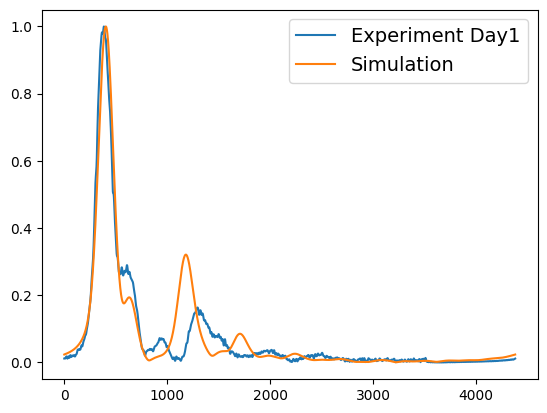

In [17]:
plt.plot(ExpTest_SLData_Pro[0],label='Experiment Day1')
plt.plot(SimTrain_Data_Pro[0],label='Simulation')
plt.legend(fontsize=14)

### Build data loader

In [18]:
# Train loader
SimTrain_Data_Pro_Tensor = torch.tensor(SimTrain_Data_Pro, dtype=torch.float32)
SimTrain_Label_Pro_Tensor = torch.tensor(SimTrain_Label_Pro[:,material_param], dtype=torch.float32)
Train_Dataset = TensorDataset(SimTrain_Data_Pro_Tensor,SimTrain_Label_Pro_Tensor)
Train_Loader = DataLoader(Train_Dataset, batch_size, shuffle=True)

## Build PatchTST model

In [19]:
PatchTST = PatchTSTMaterialRegressor(
    seq_len=4381,
    out_dim=5,
    c_in=1,
    patch_len=256,
    stride=64,
    d_model=64,
    n_heads=4,
    n_layers=2,
    d_ff=256,
    dropout=0.1,
    revin=True,
    decomposition=False,
    pool_vars="mean",
).to(device)

summary(
    PatchTST,
    input_size=(1, 4381),   # (batch_size, L)
    device=str(device)
)


Layer (type:depth-idx)                                                 Output Shape              Param #
PatchTSTMaterialRegressor                                              [1, 5]                    --
├─PatchTST_backbone: 1-1                                               [1, 1, 64, 65]            4,161
│    └─RevIN: 2-1                                                      [1, 4381, 1]              2
│    └─TSTiEncoder: 2-2                                                [1, 1, 64, 65]            4,160
│    │    └─Linear: 3-1                                                [1, 1, 65, 64]            16,448
│    │    └─Dropout: 3-2                                               [1, 65, 64]               --
│    │    └─TSTEncoder: 3-3                                            [1, 65, 64]               99,970
├─Sequential: 1-2                                                      [1, 5]                    --
│    └─LayerNorm: 2-3                                                  [1, 4160]  

## Utility functions

In [20]:
def _save_checkpoint(epoch):
    ckp = PatchTST.state_dict()
    path = f'./Saved_Model/PatchTST_Model_{model_num}/checkpoint_{epoch+1}.pt'
    torch.save(ckp, path)
    with open(f'./Saved_Model/PatchTST_Model_{model_num}/trainHistoryDict_{epoch+1}', 'wb') as file_pi:
        pickle.dump(loss_hist, file_pi)
    print(f'Epoch {epoch+1} | Training checkpoint saved at {path}')

In [21]:
def _load_checkpoint(epoch):
# Load trained PatchTST
    path = f'./Saved_Model/PatchTST_Model_{model_num}/checkpoint_{epoch}.pt'
    sd = torch.load(path, map_location="cpu", weights_only=False)  # ONLY if you trust the file

    # If this is a checkpoint dict, extract the state dict
    if isinstance(sd, dict) and any(k in sd for k in ["model_state_dict", "state_dict"]):
        sd = sd.get("model_state_dict", sd.get("state_dict"))
    
    # Remove non-parameter bookkeeping if present
    if isinstance(sd, dict):
        sd.pop("_metadata", None)

    PatchTST.load_state_dict(sd, strict=True)

## Compile and train PatchTST model

In [22]:
# Instantiate and train
PatchTST = PatchTSTMaterialRegressor(
    seq_len=4381,
    out_dim=5,
    c_in=1,
    patch_len=256,
    stride=64,
    d_model=64,
    n_heads=4,
    n_layers=2,
    d_ff=256,
    dropout=0.1,
    revin=True,
    decomposition=False,
    pool_vars="mean",
).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(PatchTST.parameters(), lr=learning_rate, weight_decay=1e-2)

In [23]:
# Training loop
start_time = time.time()
loss_hist = []

for epoch in range(num_epochs):
    PatchTST.train()
    epoch_loss = 0.0

    for batch_x, batch_y in Train_Loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).float()

        pred = PatchTST(batch_x)
        loss = criterion(pred, batch_y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(Train_Loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")
    loss_hist.append(avg_loss)

    if save_every is not None and (epoch+1) % save_every == 0:
        _save_checkpoint(epoch)

end_time = time.time()
print(f"Training time: {(end_time - start_time) / 60:.1f} min")

Epoch 1/20, Loss: 0.046490
Epoch 2/20, Loss: 0.033730
Epoch 3/20, Loss: 0.032379
Epoch 4/20, Loss: 0.032299
Epoch 5/20, Loss: 0.031847
Epoch 6/20, Loss: 0.031272
Epoch 7/20, Loss: 0.029732
Epoch 8/20, Loss: 0.028918
Epoch 9/20, Loss: 0.027825
Epoch 10/20, Loss: 0.026933
Epoch 10 | Training checkpoint saved at ./Saved_Model/PatchTST_Model_22/checkpoint_10.pt
Epoch 11/20, Loss: 0.026200
Epoch 12/20, Loss: 0.025136
Epoch 13/20, Loss: 0.024097
Epoch 14/20, Loss: 0.024118
Epoch 15/20, Loss: 0.024936
Epoch 16/20, Loss: 0.024849
Epoch 17/20, Loss: 0.024058
Epoch 18/20, Loss: 0.024085
Epoch 19/20, Loss: 0.023327
Epoch 20/20, Loss: 0.023235
Epoch 20 | Training checkpoint saved at ./Saved_Model/PatchTST_Model_22/checkpoint_20.pt
Training time: 2.9 min


## Test loss curve

In [22]:
Test_R_all = np.zeros((int(num_epochs/save_every),1))

for j in range(int(num_epochs/save_every)):
    
    # Load trained FNO
    _load_checkpoint((j+1)*10)
    
    # Evaluate using the testing dataset
    PatchTST.eval()
    with torch.no_grad():
        ExpTest_Pred_Pro = PatchTST(torch.unsqueeze(torch.tensor(ExpTest_SLData_Pro, dtype=torch.float32),1).to(device))
    ExpTest_Pred_Pro = ExpTest_Pred_Pro.cpu().numpy()

    # De-normalize the predictions
    ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

    for i in range(ExpTest_Pred_Pro.shape[1]):
        ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * \
            (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])
    
    # Calculate R
    Test_R_all[j] = np.corrcoef(ExpTest_SLLabel[:,0].astype(float), ExpTest_Pred[:,0].astype(float))[0,1]

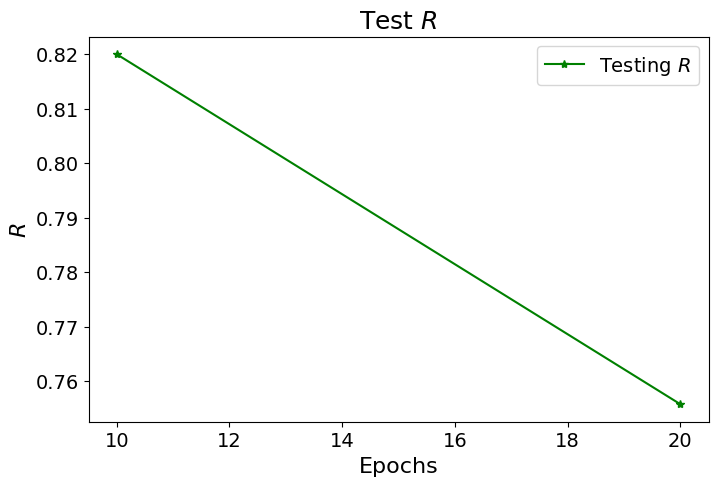

The highest test R is achieved at Epoch: 10


In [23]:
fig = plt.figure(figsize=(8, 5))
plt.plot(range(10,num_epochs+1,10), Test_R_all, 'g-*', label='Testing $R$')
plt.title('Test $R$',fontsize=18)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('$R$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

epoch = int((np.where(Test_R_all == Test_R_all.max())[0][0] + 1) * 10)
print(f'The highest test R is achieved at Epoch: {epoch}')

## Load trained PatchTST model

In [24]:
select_epochs = 10

In [25]:
# Load trained PatchTST
_load_checkpoint(select_epochs)

# Load train history
with open(f'./Saved_Model/PatchTST_Model_{model_num}/trainHistoryDict_{select_epochs}', 'rb') as file_pi:
        loss_hist = pickle.load(file_pi)

## Evaluate using experimental tesing dataset

In [26]:
# Evaluate using the experimental testing dataset
PatchTST.eval()

start_time = time.time()

with torch.no_grad():
    ExpTest_Pred_Pro = PatchTST(torch.unsqueeze(torch.tensor(ExpTest_SLData_Pro, dtype=torch.float32),1).to(device))
ExpTest_Pred_Pro = ExpTest_Pred_Pro.cpu().numpy()

end_time = time.time()
print(f"Inference time per scan: {(end_time - start_time)/ExpTest_Pred_Pro.shape[0]:.6f} sec")
    
# De-normalize the predictions
ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

for i in range(ExpTest_Pred_Pro.shape[1]):
    ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * \
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])

# Mean square error
ExpTest_MSE_p1 = np.mean((ExpTest_Pred[:,0] - ExpTest_SLLabel[:,0]) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1))

# R^2
ExpTest_R2_p1 = r2_score(ExpTest_SLLabel[:,0], ExpTest_Pred[:,0])
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1))

# R
ExpTest_R_p1 = np.corrcoef(ExpTest_SLLabel[:,0].astype(float), ExpTest_Pred[:,0].astype(float))[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1))

# Bias
ExpTest_Bias_p1 = np.mean(ExpTest_Pred[:,0]) - np.mean(ExpTest_SLLabel[:,0])
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1))

Inference time per scan: 0.000010 sec
p1 MSE on experimental tesing dataset: 3.7330270773
p1 R2 on experimental tesing dataset: 0.6460559824
p1 R on experimental tesing dataset: 0.8200023416
p1 Bias on experimental tesing dataset: 0.3457551217


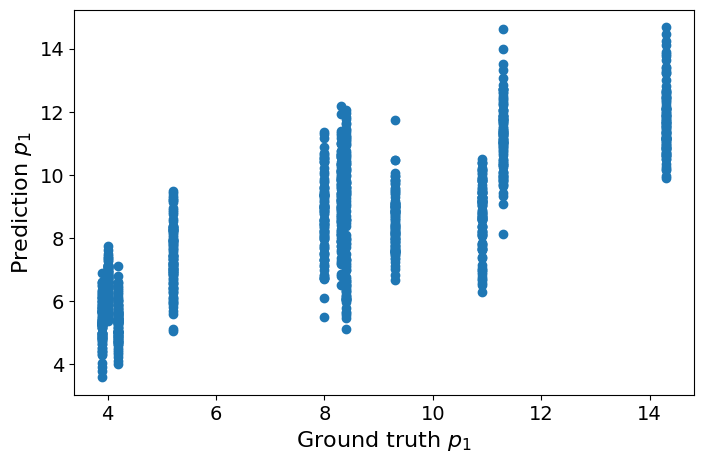

In [27]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_SLLabel[:,0],ExpTest_Pred[:,0])
plt.xlabel('Ground truth $p_1$',fontsize=16)
plt.ylabel('Prediction $p_1$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Information fusion

### Soil permittivity

In [28]:
day1_pred_mean_p1 = np.mean(ExpTest_Pred[0:100,0])
day2_pred_mean_p1 = np.mean(ExpTest_Pred[100:200,0])
day3_pred_mean_p1 = np.mean(ExpTest_Pred[200:300,0])
day4_pred_mean_p1 = np.mean(ExpTest_Pred[300:400,0])
day5_pred_mean_p1 = np.mean(ExpTest_Pred[400:500,0])
day6_pred_mean_p1 = np.mean(ExpTest_Pred[500:600,0])
day7_pred_mean_p1 = np.mean(ExpTest_Pred[600:700,0])
day8_pred_mean_p1 = np.mean(ExpTest_Pred[700:800,0])
day9_pred_mean_p1 = np.mean(ExpTest_Pred[800:900,0])
day10_pred_mean_p1 = np.mean(ExpTest_Pred[900:1000,0])
day11_pred_mean_p1 = np.mean(ExpTest_Pred[1000:1100,0])
ExpTest_Pred_p1_mean = np.array([day1_pred_mean_p1,day2_pred_mean_p1,day3_pred_mean_p1,
                                day4_pred_mean_p1,day5_pred_mean_p1,day6_pred_mean_p1,
                                day7_pred_mean_p1,day8_pred_mean_p1,day9_pred_mean_p1,
                                day10_pred_mean_p1,day11_pred_mean_p1])
# R
R_daily_p1 = np.corrcoef(label[:,0].astype(float), ExpTest_Pred_p1_mean.astype(float))[0,1]
print('daily p1 R on experimental tesing dataset: %.10f' % (R_daily_p1))

# Bias
Bias_daily_p1 = np.mean(ExpTest_Pred_p1_mean) - np.mean(label[:,0])
print('daily p1 bias on experimental tesing dataset: %.10f' % (Bias_daily_p1))

# MSE
MSE_daily_p1 = np.square(np.subtract(label[:,0],ExpTest_Pred_p1_mean)).mean()
print('daily p1 MSE on experimental tesing dataset: %.10f' % (MSE_daily_p1))

# RMSE
RMSE_daily_p1 = np.sqrt(MSE_daily_p1)
print('daily p1 RMSE on experimental tesing dataset: %.10f' % (RMSE_daily_p1))

# ubRMSE
ubRMSE_daily_p1 = np.sqrt((RMSE_daily_p1 ** 2 - Bias_daily_p1 ** 2))
print('daily p1 ubRMSE on experimental tesing dataset: %.10f' % (ubRMSE_daily_p1))

daily p1 R on experimental tesing dataset: 0.9344544383
daily p1 bias on experimental tesing dataset: 0.3457551217
daily p1 MSE on experimental tesing dataset: 2.5531600969
daily p1 RMSE on experimental tesing dataset: 1.5978611006
daily p1 ubRMSE on experimental tesing dataset: 1.5600043246


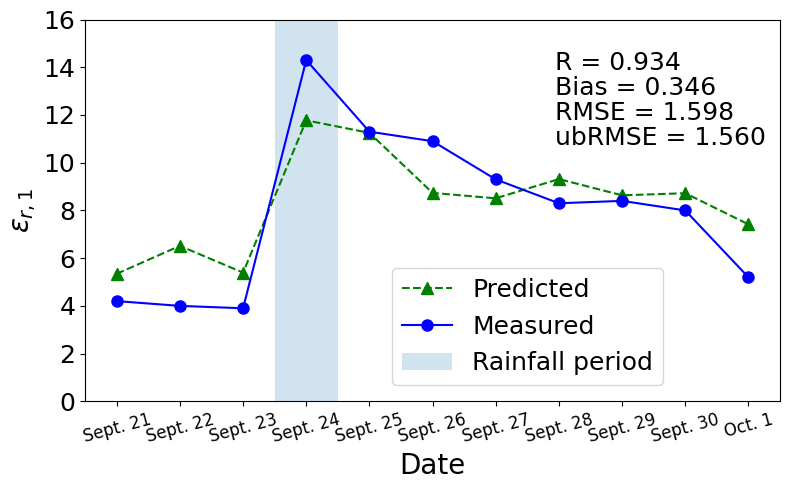

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),ExpTest_Pred_p1_mean,
         color = 'green', linestyle = '--', marker = '^',
         markerfacecolor = 'green', markersize = 8, label = 'Predicted')
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),label[:,0],
         color = 'blue', linestyle = '-', marker = 'o',
         markerfacecolor = 'blue', markersize = 8, label = 'Measured')
rectangle = patches.Rectangle((3.5, 0), 1, 16, facecolor='C0', alpha=0.2, label = 'Rainfall period')
ax.add_patch(rectangle)
plt.figtext(0.7, 0.85, f'R = %.3f' % R_daily_p1, fontsize=18)
plt.figtext(0.7, 0.80, f'Bias = %.3f' % Bias_daily_p1, fontsize=18)
plt.figtext(0.7, 0.75, f'RMSE = %.3f' % RMSE_daily_p1, fontsize=18)
plt.figtext(0.7, 0.70, f'ubRMSE = %.3f' % ubRMSE_daily_p1, fontsize=18)
plt.xlabel('Date',fontsize=20)
plt.ylabel(r'$\varepsilon_{r,1}$', fontsize=20)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11], ['Sept. 21', 'Sept. 22', 'Sept. 23', 'Sept. 24', 'Sept. 25', 'Sept. 26', 'Sept. 27', 'Sept. 28', 'Sept. 29', 'Sept. 30', 'Oct. 1'])
plt.xticks(fontsize=12, rotation=15)
plt.yticks(fontsize=18)
plt.legend(fontsize=18,loc='lower right',bbox_to_anchor=(0.85, 0.01))
plt.ylim([0,16])
plt.tight_layout()
plt.show()
fig.savefig('./FieldTest_SoilPermitivity_PatchTST_SL', dpi=600)

daily p1 bias on experimental tesing dataset: 0.0359644887
daily p1 MSE on experimental tesing dataset: 0.0038563370
daily p1 RMSE on experimental tesing dataset: 0.0620994126
daily p1 ubRMSE on experimental tesing dataset: 0.0506250194


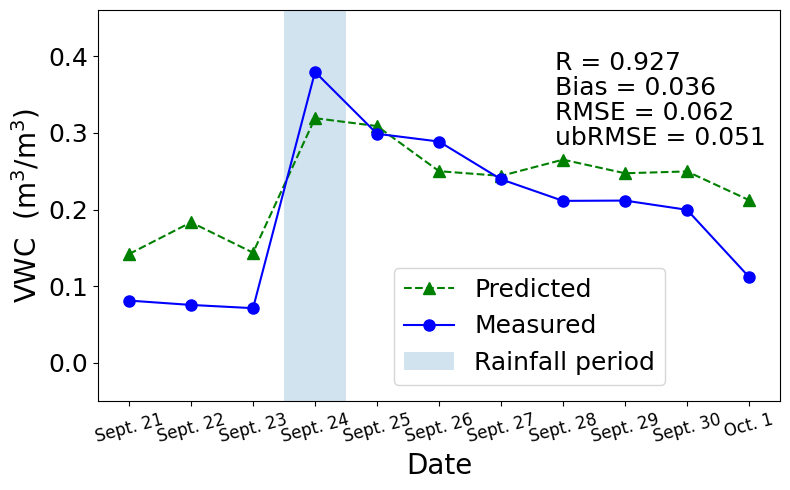

In [30]:
x=ExpTest_Pred_p1_mean; 
RAW= [2006.8, 1996.4, 1988.7, 2552.6, 2404.9, 2386.4,2296.3,2244.8,2245.5,2223.5, 2063.3]

VWC_Grav = 5.46e-04*np.array(RAW) - 1.0144                  # Calibration equation from RAW to VWC(gravimetric) - is in excel sheet
VWC_GPR = 3E-05*x**3 - 0.0022*x**2 + 0.0583*x - 0.1114      # Calibration equation from GPR permittivity to VWC(gravimetric) - is in excel sheet

R_daily_p1 = np.corrcoef(VWC_Grav, VWC_GPR)[0, 1]

# Bias
Bias_daily_p1 = np.mean(VWC_GPR) - np.mean(VWC_Grav)
print('daily p1 bias on experimental tesing dataset: %.10f' % (Bias_daily_p1))

# MSE
MSE_daily_p1 = np.square(np.subtract(VWC_Grav,VWC_GPR)).mean()
print('daily p1 MSE on experimental tesing dataset: %.10f' % (MSE_daily_p1))

# RMSE
RMSE_daily_p1 = np.sqrt(MSE_daily_p1)
print('daily p1 RMSE on experimental tesing dataset: %.10f' % (RMSE_daily_p1))

# ubRMSE
ubRMSE_daily_p1 = np.sqrt((RMSE_daily_p1 ** 2 - Bias_daily_p1 ** 2))
print('daily p1 ubRMSE on experimental tesing dataset: %.10f' % (ubRMSE_daily_p1))


fig, ax = plt.subplots(figsize=(8, 5))
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),VWC_GPR,
         color = 'green', linestyle = '--', marker = '^',
         markerfacecolor = 'green', markersize = 8, label = 'Predicted')
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),VWC_Grav,
         color = 'blue', linestyle = '-', marker = 'o',
         markerfacecolor = 'blue', markersize = 8, label = 'Measured')
rectangle = patches.Rectangle((3.5, -0.05), 1, 0.55, facecolor='C0', alpha=0.2, label = 'Rainfall period')
ax.add_patch(rectangle)
plt.figtext(0.7, 0.85, f'R = %.3f' % R_daily_p1, fontsize=18)
plt.figtext(0.7, 0.80, f'Bias = %.3f' % Bias_daily_p1, fontsize=18)
plt.figtext(0.7, 0.75, f'RMSE = %.3f' % RMSE_daily_p1, fontsize=18)
plt.figtext(0.7, 0.70, f'ubRMSE = %.3f' % ubRMSE_daily_p1, fontsize=18)
# plt.figtext(0.15, 0.75, f'Bias = %.3f' % bias_soil, fontsize=16)
plt.xlabel('Date',fontsize=20)
plt.ylabel(r'VWC  $\mathrm{(m^3/m^3)}$', fontsize=20)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11], ['Sept. 21', 'Sept. 22', 'Sept. 23', 'Sept. 24', 'Sept. 25', 'Sept. 26', 'Sept. 27', 'Sept. 28', 'Sept. 29', 'Sept. 30', 'Oct. 1'])
plt.xticks(fontsize=12, rotation=15)
plt.yticks(fontsize=18)
plt.legend(fontsize=18,loc='lower right',bbox_to_anchor=(0.85, 0.01))
plt.ylim(-0.05, 0.46)
plt.tight_layout()
plt.show()
fig.savefig('./FieldTest_VWC_PatchTST_SL', dpi=600)

### Soil conductivity

In [31]:
day1_pred_mean_c1 = np.mean(ExpTest_Pred[0:100,1])
day2_pred_mean_c1 = np.mean(ExpTest_Pred[100:200,1])
day3_pred_mean_c1 = np.mean(ExpTest_Pred[200:300,1])
day4_pred_mean_c1 = np.mean(ExpTest_Pred[300:400,1])
day5_pred_mean_c1 = np.mean(ExpTest_Pred[400:500,1])
day6_pred_mean_c1 = np.mean(ExpTest_Pred[500:600,1])
day7_pred_mean_c1 = np.mean(ExpTest_Pred[600:700,1])
day8_pred_mean_c1 = np.mean(ExpTest_Pred[700:800,1])
day9_pred_mean_c1 = np.mean(ExpTest_Pred[800:900,1])
day10_pred_mean_c1 = np.mean(ExpTest_Pred[900:1000,1])
day11_pred_mean_c1 = np.mean(ExpTest_Pred[1000:1100,1])
ExpTest_Pred_c1_mean = np.array([day1_pred_mean_c1,day2_pred_mean_c1,day3_pred_mean_c1,
                                day4_pred_mean_c1,day5_pred_mean_c1,day6_pred_mean_c1,
                                day7_pred_mean_c1,day8_pred_mean_c1,day9_pred_mean_c1,
                                day10_pred_mean_c1,day11_pred_mean_c1])

# R
R_daily_c1 = np.corrcoef(label[:,1].astype(float), ExpTest_Pred_c1_mean.astype(float))[0,1]
print('c1 R on experimental tesing dataset (daily): %.10f' % (R_daily_c1))

# Bias
Bias_daily_c1 = np.mean(ExpTest_Pred_c1_mean) - np.mean(label[:,1])
print('c1 bias on experimental tesing dataset (daily): %.10f' % (Bias_daily_c1))

# MSE
MSE_daily_c1 = np.square(np.subtract(label[:,1],ExpTest_Pred_c1_mean)).mean()
print('daily c1 MSE on experimental tesing dataset: %.10f' % (MSE_daily_c1))

# RMSE
RMSE_daily_c1 = np.sqrt(MSE_daily_c1)
print('daily c1 RMSE on experimental tesing dataset: %.10f' % (RMSE_daily_c1))

# ubRMSE
ubRMSE_daily_c1 = np.sqrt((RMSE_daily_c1 ** 2 - Bias_daily_c1 ** 2))
print('daily c1 ubRMSE on experimental tesing dataset: %.10f' % (ubRMSE_daily_c1))

c1 R on experimental tesing dataset (daily): 0.3224984462
c1 bias on experimental tesing dataset (daily): 0.0011023995
daily c1 MSE on experimental tesing dataset: 0.0013405295
daily c1 RMSE on experimental tesing dataset: 0.0366132420
daily c1 ubRMSE on experimental tesing dataset: 0.0365966420


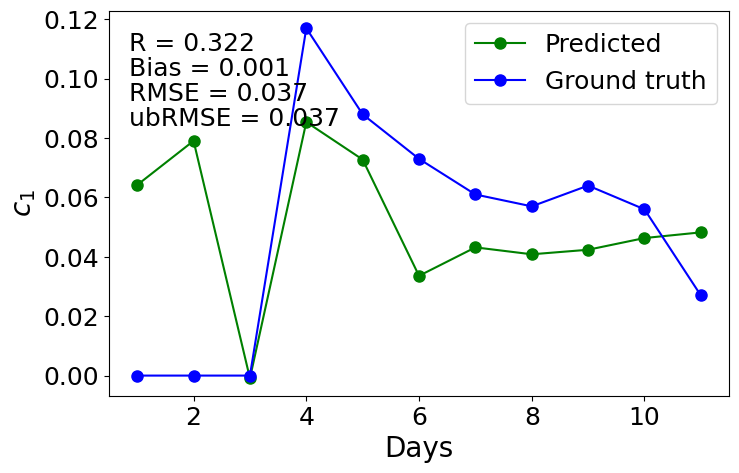

In [32]:
fig = plt.figure(figsize=(8, 5))
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),ExpTest_Pred_c1_mean,
         color = 'green', linestyle = 'solid', marker = 'o',
         markerfacecolor = 'green', markersize = 8, label = 'Predicted')
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),label[:,1],
         color = 'blue', linestyle = 'solid', marker = 'o',
         markerfacecolor = 'blue', markersize = 8, label = 'Ground truth')
plt.figtext(0.15, 0.80, f'R = %.3f' % R_daily_c1, fontsize=18)
plt.figtext(0.15, 0.75, f'Bias = %.3f' % Bias_daily_c1, fontsize=18)
plt.figtext(0.15, 0.70, f'RMSE = %.3f' % RMSE_daily_c1, fontsize=18)
plt.figtext(0.15, 0.65, f'ubRMSE = %.3f' % ubRMSE_daily_c1, fontsize=18)
plt.xlabel('Days',fontsize=20)
plt.ylabel('$c_1$',fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.show()